# Physical pseudomode mapping: coupled-pair approach

## Fitting of bath correlation function

In [ ]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib as mpl 
from scipy.linalg import expm
from numpy import linalg
from lmfit import minimize, Parameters

import sys
sys.path.append('/Users/GraemePleasance/Documents/PM theory 3/Python') # NEED?

In [3]:
# Parameters (units of system energy om_0)
T = 0.5
om_cut = 5
s = 1
N_exp = 3
alph = 0.5

tlist = np.linspace(0, 5, 500)
omlist = np.linspace(-10, 20, 500)

In [6]:
bath = qt.OhmicEnvironment(T=T, alpha=alph, wc=om_cut, s=s)
C0 = np.real(bath.correlation_function(tlist[0]))

print(f'C(t=0) = ', C0)

C(t=0) =  4.092931899686425


In [18]:
bath.correlation_function(tlist)

array([ 4.09293190e+00+0.00000000e+00j,  4.06309102e+00-3.96690816e-01j,
        3.97504637e+00-7.81596030e-01j,  3.83308034e+00-1.14379328e+00j,
        3.64385102e+00-1.47397084e+00j,  3.41575817e+00-1.76496770e+00j,
        3.15820355e+00-2.01205647e+00j,  2.88084979e+00-2.21296590e+00j,
        2.59296670e+00-2.36768039e+00j,  2.30292408e+00-2.47807986e+00j,
        2.01785705e+00-2.54749237e+00j,  1.74350009e+00-2.58022670e+00j,
        1.48416506e+00-2.58113707e+00j,  1.24282756e+00-2.55525347e+00j,
        1.02128369e+00-2.50749366e+00j,  8.20343101e-01-2.44245843e+00j,
        6.40031368e-01-2.36430241e+00j,  4.79782775e-01-2.27666741e+00j,
        3.38611875e-01-2.18266384e+00j,  2.15258300e-01-2.08488609e+00j,
        1.08303526e-01-1.98544996e+00j,  1.62611433e-02-1.88604242e+00j,
       -6.23562890e-02-1.78797670e+00j, -1.28990040e-01-1.69224758e+00j,
       -1.85003856e-01-1.59958385e+00j, -2.31664917e-01-1.51049597e+00j,
       -2.70134059e-01-1.42531811e+00j, -3.01462705

In [ ]:
# Fitting
def residuals(params, t, C):
    #
    r1_r = params['real_residue_1'].value
    r1_i = params['imag_residue_1'].value
    r2_r = params['real_residue_2'].value
    r2_i = params['imag_residue_2'].value
    r3_r = params['real_residue_2'].value
    r3_i = params['imag_residue_2'].value
    z1_r = params['z1_r'].value
    z1_i = params['z1_i'].value
    z2_r = params['z2_r'].value
    z2_i = params['z2_i'].value
    z3_r = params['z3_r'].value
    z3_i = params['z3_i'].value

    C_fit =  -1.0j*(r1_r + 1.0j*r1_i)*np.exp(-1j*(z1_r - 1j*z1_i)*tlist) \
          +  -1.0j*(r2_r + 1.0j*r2_i)*np.exp(-1j*(z2_r - 1j*z2_i)*tlist) \
          +  -1.0j*(r3_r + 1.0j*r3_i)*np.exp(-1j*(z3_r - 1j*z3_i)*tlist)
            
    residual_corr = C - C_fit
    
    return residual_corr.view(float)

params = Parameters() 
params.add('norm', value=C0, vary=False)
params.add('real_residue_1', value=1)
params.add('imag_residue_1', value=1)
params.add('real_residue_2', value=0, vary=False)
params.add('imag_residue_2', value=1)
params.add('real_residue_3', value=0, vary=False)
params.add('imag_residue_3', expr='norm-imag_residue_1-imag_residue_2')
params.add('z1_r', value=1)
params.add('z1_i', value=1)
params.add('z2_r', value=1)
params.add('z2_i', value=1)
params.add('z3_r', value=1)
params.add('z3_i', value=1)

result = minimize(residuals, params, method='leastsq', args=(tlist, bath.correlation_function(tlist)))

# Get fit parameters 
r1_r = result.params['real_residue_1'].value
r1_i = result.params['imag_residue_1'].value
r2_r = result.params['real_residue_2'].value
r2_i = result.params['imag_residue_2'].value
r3_r = result.params['real_residue_3'].value
r3_i = result.params['imag_residue_3'].value
z1_r = result.params['z1_r'].value
z1_i = result.params['z1_i'].value
z2_r = result.params['z2_r'].value
z2_i = result.params['z2_i'].value
z3_r = result.params['z3_r'].value
z3_i = result.params['z3_i'].value

/Users/GraemePleasance/anaconda3/envs/qutip-env/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


np.float64(3.809851389514206)

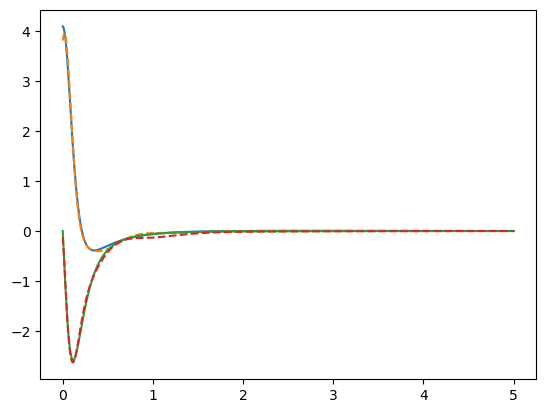

In [ ]:
plt.plot(tlist, np.real(bath.correlation_function(tlist)))
plt.plot(tlist, np.real(bath.correlation_function(tlist)) + result.residual[int(0):int(1e3):2] ,linestyle='--')
plt.plot(tlist, np.imag(bath.correlation_function(tlist)))
plt.plot(tlist, np.imag(bath.correlation_function(tlist)) + result.residual[int(1):int(1e3):2] ,linestyle='--')

In [36]:
(np.imag(bath.correlation_function(tlist)) + result.residual[int(1):int(1e3):2])[0]

np.float64(-0.19277570119816922)